In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

D:\Promotion\neurolib\GUI\gui\data\10000
1


### Bistability

In [48]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

152


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur = 100
dur_pre = 10
dur_post = 10

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[2] == '0':
    cntrl_vars_0 = [0,1]
elif case[2] == '1':
    cntrl_vars_0 = [2,3,4,5]
    
if case[3] == '0':
    maxC = [5., -5., 0.18, 0.]
elif case[3] == '1':
    maxC = [500., -500., 18., 0.]
    
if case[4] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[4] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[4] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[4] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

prec_vars = [0]
trans_time = 0.8
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [11]:
i_stepsize = 13
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  65 0.5500000000000003 0.6250000000000003
-------  78 0.5250000000000001 0.6750000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  104 0.4250000000000001 0.7750000000000005
-------  117 0.5500000000000003 0.8000000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  0 , total integrated cost =  17551.147823015366
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17068.886839794224
Gradient descend method:  None
RUN  0 , total integrated cost =  17068.886839794224
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  39 0.5250000000000001 0.5250000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

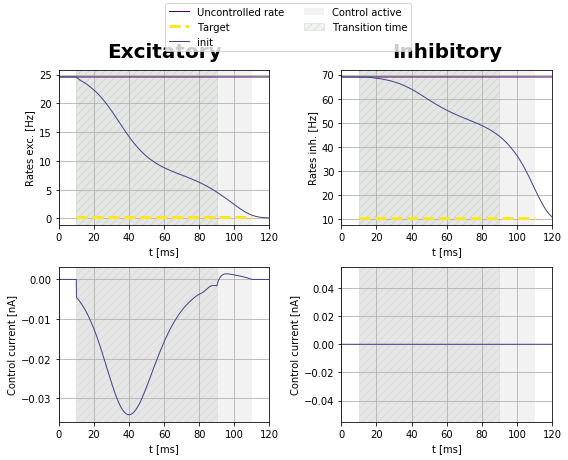

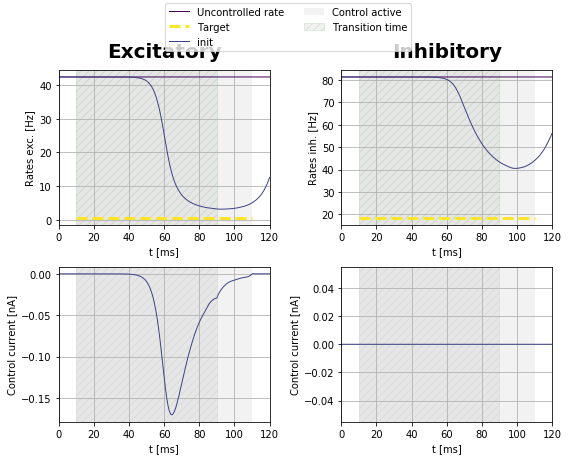

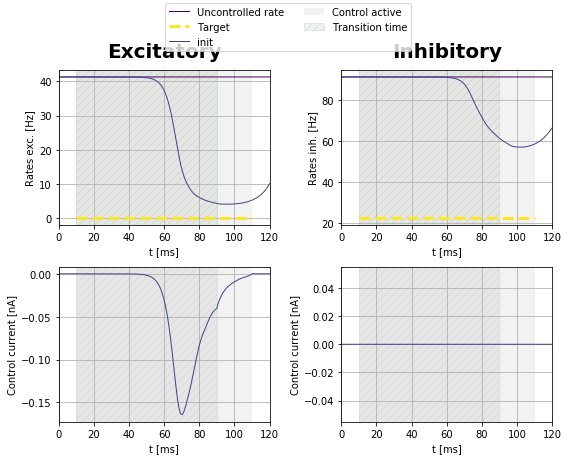

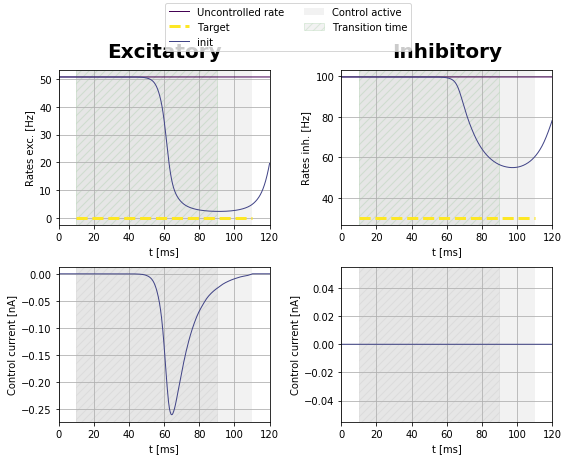

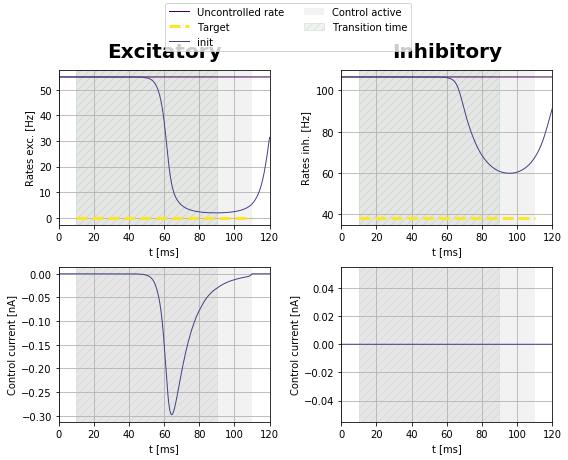

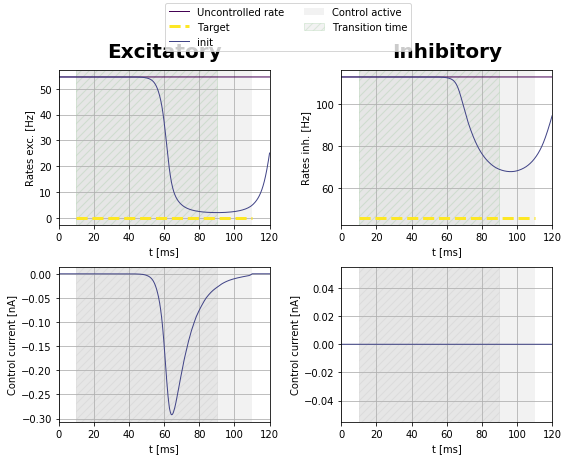

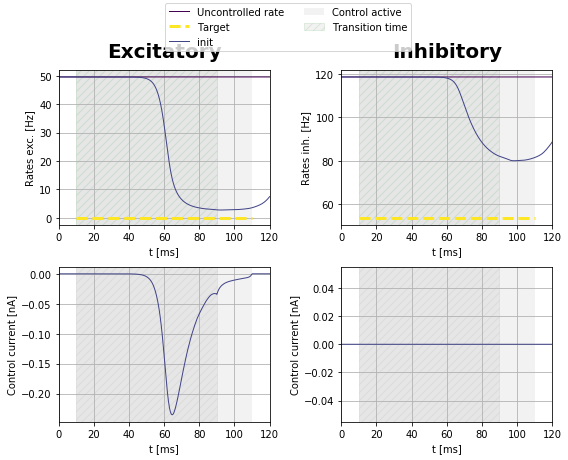

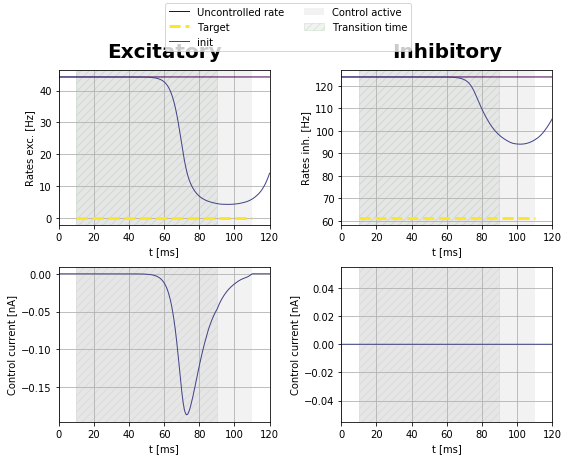

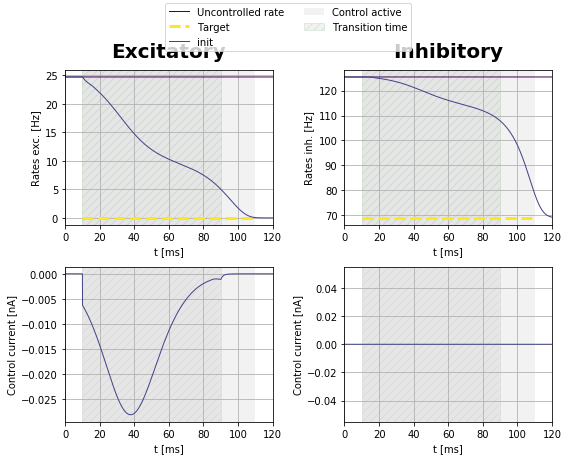

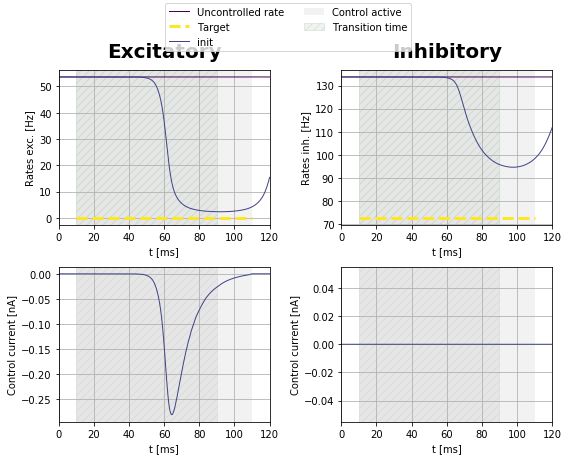

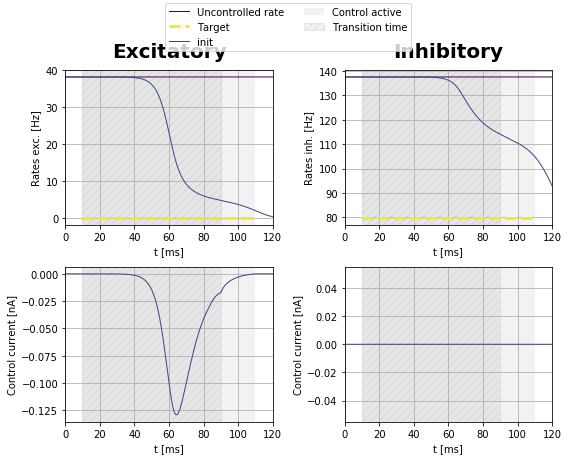

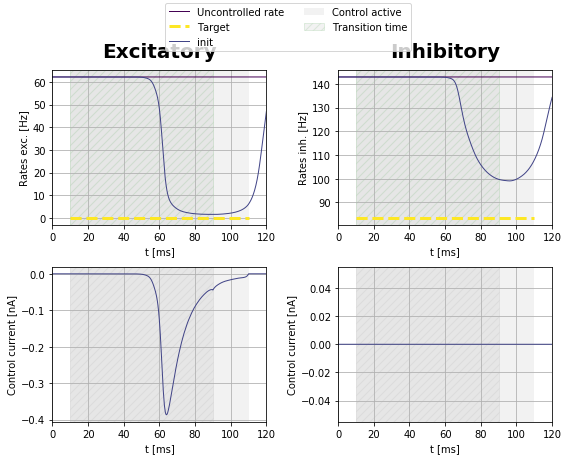

In [50]:
#plot initial guesses

for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [49]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 152
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  13 0.47500000000000014 0.40000000000000013
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
inter

ERROR:root:Problem in initial value trasfer


RUN  80 , total integrated cost =  34.70199556928999
Control only changes marginally.
RUN  80 , total integrated cost =  34.70199556928999
Improved over  80  iterations in  1.899126900000283  seconds by  99.80338290986097  percent.
Problem in initial value trasfer:  Vmean_exc -61.96892518036824 -61.97158542033829
weight =  5057.67680938427
set cost params:  1.0 0.0 5057.67680938427
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17235.655769728415
Gradient descend method:  None
RUN  1 , total integrated cost =  16027.762176482349
RUN  2 , total integrated cost =  16000.404556998275
RUN  3 , total integrated cost =  15976.566785130075
RUN  4 , total integrated cost =  15941.005208329621
RUN  5 , total integrated cost =  15912.208024022673
RUN  6 , total integrated cost =  15810.659052261
RUN  7 , total integrated cost =  15760.631505028832
RUN  8 , total integrated cost =  15757.301409499934
RUN  9 , total integrated cost =  15751.810980128268
RUN  10 , total int

ERROR:root:Problem in initial value trasfer


RUN  16 , total integrated cost =  15708.666586068013
RUN  17 , total integrated cost =  15708.666586068008
RUN  18 , total integrated cost =  15708.666586068006
RUN  19 , total integrated cost =  15708.666586068006
Control only changes marginally.
RUN  19 , total integrated cost =  15708.666586068006
Improved over  19  iterations in  0.5131468999998106  seconds by  8.859478305097696  percent.
Problem in initial value trasfer:  Vmean_exc -57.08711228566827 -57.075956009761015
-------  26 0.47500000000000014 0.4750000000000002
found solution for  26
-------  39 0.5250000000000001 0.5250000000000002
[0, 26] []
closest index  26
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22219.96237861558
Gradient descend method:  None
RUN  1 , total integrated cost =  90.86025372415945
RUN  2 , total integrated cost =  84.34586298655721
RUN  3 , total integrated cost =  77.86479024373864
RUN  4 , total integrated cost =  74

...

RUN  11 , total integrated cost =  28750.032350365433
RUN  12 , total integrated cost =  28750.03235036543
RUN  13 , total integrated cost =  28750.03235036542
RUN  14 , total integrated cost =  28750.03235036542
Control only changes marginally.
RUN  14 , total integrated cost =  28750.03235036542
Improved over  14  iterations in  0.4001939999998285  seconds by  2.6990947482556322  percent.
Problem in initial value trasfer:  Vmean_exc -57.87831074284665 -57.86099220474368
-------  78 0.5250000000000001 0.6750000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  104 0.4250000000000001 0.7750000000000005
-------  117 0.5500000000000003 0.8000000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006
closest index  -1
set cost params:  1.0 0.0 10.0
all options tried already
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  35494.10354389749
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  50 , total integrated cost =  58.76388714328006
Control only changes marginally.
RUN  51 , total integrated cost =  58.76388714328006
Improved over  51  iterations in  1.3084939000000304  seconds by  99.83444042453247  percent.
Problem in initial value trasfer:  Vmean_exc -64.80761555290437 -64.81065593522843
weight =  6570.874367286404
set cost params:  1.0 0.0 6570.874367286404
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38368.70793881682
Gradient descend method:  None
RUN  1 , total integrated cost =  37623.6392903971
RUN  2 , total integrated cost =  37622.77894208145
RUN  3 , total integrated cost =  37621.47123969205
RUN  4 , total integrated cost =  37621.13267802399
RUN  5 , total integrated cost =  37617.550180619895
RUN  6 , total integrated cost =  37614.735517771995
RUN  7 , total integrated cost =  37613.823559651275
RUN  8 , total integrated cost =  37612.45220860002
RUN  9 , total integrated cost =  37612.16133716578
RUN  10 , total integ

ERROR:root:Problem in initial value trasfer


RUN  37 , total integrated cost =  37542.58222892286
Improved over  37  iterations in  0.9316352000000734  seconds by  2.153123611072104  percent.
Problem in initial value trasfer:  Vmean_exc -57.58477280383533 -57.56026835677351
------------------------------------------------------------
-------------------- 9
------------------------------------------------------------
found solution:  [0, 26, 91, 104, 130, 13, 78, 117]
no solution:  [39, 52, 65, 143]
found solution for all parameters


In [52]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  5596.019546650086
set cost params:  1.0 0.0 5596.019546650086
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17543.860661351617
Gradient descend method:  None
RUN  1 , total integrated cost =  17543.78164269208
RUN  2 , total integrated cost =  17543.781642692073
RUN  3 , total integrated cost =  17543.78164269207
RUN  4 , total integrated cost =  17543.78164269207


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  4 , total integrated cost =  17543.78164269207
Improved over  4  iterations in  0.17270420000022568  seconds by  0.00045040633342807723  percent.
Problem in initial value trasfer:  Vmean_exc -57.79810471769907 -57.78859584108827
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
no convergence
weight =  6138.3795986782225
set cost params:  1.0 0.0 6138.3795986782225
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  25751.43449537696
Gradient descend method:  None
RUN  1 , total integrated cost =  25751.383031899448
RUN  2 , total integrated cost =  25751.38268109186
RUN  3 , total integrated cost =  25751.382675303958
RUN  4 , total integrated cost =  25751.382674873894
RUN  5 , total integrated cost =  25751.382674833254
RUN  6 , total integrated cost =  25751.382674829638


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  25751.382674829438
RUN  8 , total integrated cost =  25751.382674829427
RUN  9 , total integrated cost =  25751.3826748294
RUN  10 , total integrated cost =  25751.382674829394
RUN  11 , total integrated cost =  25751.38267482939
RUN  12 , total integrated cost =  25751.382674829383
RUN  13 , total integrated cost =  25751.382674829383
Control only changes marginally.
RUN  13 , total integrated cost =  25751.382674829383
Improved over  13  iterations in  0.34972220000008747  seconds by  0.00020123363452739795  percent.
Problem in initial value trasfer:  Vmean_exc -57.85039085608186 -57.83537207023936
-------  52 0.5500000000000003 0.5750000000000003
no convergence
weight =  6334.437299712746
set cost params:  1.0 0.0 6334.437299712746
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30183.245223882343
Gradient descend method:  None
RUN  1 , total integrated cost =  30183.21284727506
RUN  2 , total integrated cost =  30183.2121620

...

RUN  1 , total integrated cost =  25755.495113630986
Control only changes marginally.
RUN  1 , total integrated cost =  25755.495113630986
Improved over  1  iterations in  0.0721864000001915  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -57.85036807551527 -57.83534896461724
-------  52 0.5500000000000003 0.5750000000000003
no convergence
weight =  6335.122929487862
set cost params:  1.0 0.0 6335.122929487862
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30186.469307395953
Gradient descend method:  None
RUN  1 , total integrated cost =  30186.46930739594
RUN  2 , total integrated cost =  30186.469307395917
RUN  3 , total integrated cost =  30186.469307395913
RUN  4 , total integrated cost =  30186.469307395895
RUN  5 , total integrated cost =  30186.46930739589


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  30186.46930739589
Control only changes marginally.
RUN  6 , total integrated cost =  30186.46930739589
Improved over  6  iterations in  0.22716070000024047  seconds by  1.9895196601282805e-13  percent.
Problem in initial value trasfer:  Vmean_exc -57.69191447402139 -57.67224314529231
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
converged for  117
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  143 0.6000000000000003 0.8750000000000006
no convergence
weight =  6757.628299395082
set cost params:  1.0 0.0 6757.628299395082
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38607.29882151424
Gradient descend method:  None
RUN  1 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Problem in initial value trasfer:  Vmean_exc -57.79767682080953 -57.788163130939964
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
no convergence
weight =  6335.122935666006
set cost params:  1.0 0.0 6335.122935666006
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30186.469336745864
Gradient descend method:  None
RUN  1 , total integrated cost =  30186.469336745864
Control only changes marginally.
RUN  1 , total integrated cost =  30186.469336745864
Improved over  1  iterations in  0.06533979999994699  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -57.69191447402139 -57.67224314529231
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0

In [29]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
0
13
26
39
52
65
78
91
104
117
130
143


In [30]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [31]:
"""
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)
"""

[]


In [35]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  78 0.5250000000000001 0.6750000000000004
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  165.65151596504057
Gradient descend method:  None
RUN  1 , total integrated cost =  44.98996594656566
RUN  2 , total integrated cost =  40.17799745893957
RUN  3 , total integrated cost =  39.74598659025528
RUN  4 , total integrated cost =  39.62117861609905
RUN  5 , total integrated cost =  39.51271848724585
RUN  6 , total integrated cost =  39.45095427657541
RUN  7 , total integrated cost =  39.38843149210679
RUN  8 , total integrated cost =  39.34687136683034
RUN  9 , total integrated cost =  39.29184341060787
RUN  10 , total integrated cost =  39.25252120374226
RUN  11 , total integrated cost =  39.179919587310614
RUN  12 , total integrated cost =  39.12686894969181
RUN  13 , total integrated cost =  39.03724190045579
RUN  14 , total integrated cost =  38.98151982517488
RUN  15 , total integrated cost =  38.95457376854354
RUN  16 , 

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  381.3142502566127
Control only changes marginally.
RUN  40 , total integrated cost =  381.3142502566127
Improved over  40  iterations in  4.741165599999931  seconds by  1.035018275036478  percent.
Problem in initial value trasfer:  Vmean_exc -56.70192928243117 -56.7019287136467
weight =  6443.724846193628
set cost params:  1.0 0.0 6443.724846193628
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24561.653958638388
Gradient descend method:  None
RUN  1 , total integrated cost =  24450.787414859547
RUN  2 , total integrated cost =  24450.585886630706
RUN  3 , total integrated cost =  24450.580543723707
RUN  4 , total integrated cost =  24450.579759488814
RUN  5 , total integrated cost =  24450.57963729221
RUN  6 , total integrated cost =  24450.579612942627
RUN  7 , total integrated cost =  24450.579607706848
RUN  8 , total integrated cost =  24450.57960662537
RUN  9 , total integrated cost =  24450.579606385738
RUN  10 , total i

ERROR:root:Problem in initial value trasfer


RUN  18 , total integrated cost =  24450.57960630945
RUN  19 , total integrated cost =  24450.57960630945
Control only changes marginally.
RUN  19 , total integrated cost =  24450.57960630945
Improved over  19  iterations in  2.3186739000000216  seconds by  0.4522266803204076  percent.
Problem in initial value trasfer:  Vmean_exc -56.70192227608833 -56.70192196870816
-------  104 0.4250000000000001 0.7750000000000005
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  85.76089442222077
Gradient descend method:  None
RUN  1 , total integrated cost =  85.4661514241377
RUN  2 , total integrated cost =  85.46473489327873
RUN  3 , total integrated cost =  85.46439874485755
RUN  4 , total integrated cost =  85.4643470443812
RUN  5 , total integrated cost =  85.46359424622183
RUN  6 , total integrated cost =  85.46170353373017
RUN  7 , total integrated cost =  85.46159719252653
RUN  8 , total integrated cost =  85.4615376099253
RUN  9 , total

...

RUN  2 , total integrated cost =  6111.581988972744
RUN  3 , total integrated cost =  6111.581988972744
Control only changes marginally.
RUN  3 , total integrated cost =  6111.581988972744
Improved over  3  iterations in  0.46507759999985865  seconds by  0.0012490373400737553  percent.
Problem in initial value trasfer:  Vmean_exc -56.62564773979273 -56.62564415685167
-------  130 0.47500000000000014 0.8500000000000005
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  85.44058930645829
Gradient descend method:  None
RUN  1 , total integrated cost =  66.76861140095093
RUN  2 , total integrated cost =  66.76482917901127
RUN  3 , total integrated cost =  66.76482099118714
RUN  4 , total integrated cost =  66.76480498037218
RUN  5 , total integrated cost =  66.76353237370775
RUN  6 , total integrated cost =  66.76310559460683
RUN  7 , total integrated cost =  66.76310404735472
RUN  8 , total integrated cost =  66.76310372221556
RUN  9 , t

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  22 , total integrated cost =  666.5489054682245
Improved over  22  iterations in  2.7230021999998826  seconds by  0.14661446925519783  percent.
Problem in initial value trasfer:  Vmean_exc -56.677262609561964 -56.67726354631127
weight =  2181.5823917811267
set cost params:  1.0 0.0 2181.5823917811267
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14537.528374903002
Gradient descend method:  None
RUN  1 , total integrated cost =  14521.645293630796
RUN  2 , total integrated cost =  14521.62359170079
RUN  3 , total integrated cost =  14521.623298789638
RUN  4 , total integrated cost =  14521.623292664277
RUN  5 , total integrated cost =  14521.623292592247
RUN  6 , total integrated cost =  14521.623292590131
RUN  7 , total integrated cost =  14521.623292590106
RUN  8 , total integrated cost =  14521.6232925901
RUN  9 , total integrated cost =  14521.623292590091


ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  14521.623292590086
RUN  11 , total integrated cost =  14521.623292590086
Control only changes marginally.
RUN  11 , total integrated cost =  14521.623292590086
Improved over  11  iterations in  1.542513599999893  seconds by  0.10940705945843376  percent.
Problem in initial value trasfer:  Vmean_exc -56.67716864685065 -56.677171833245076


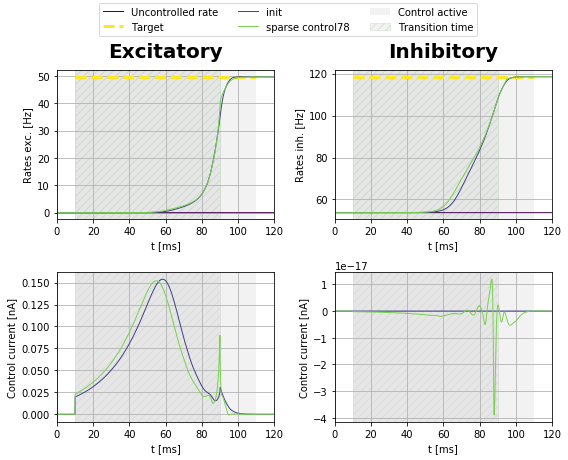

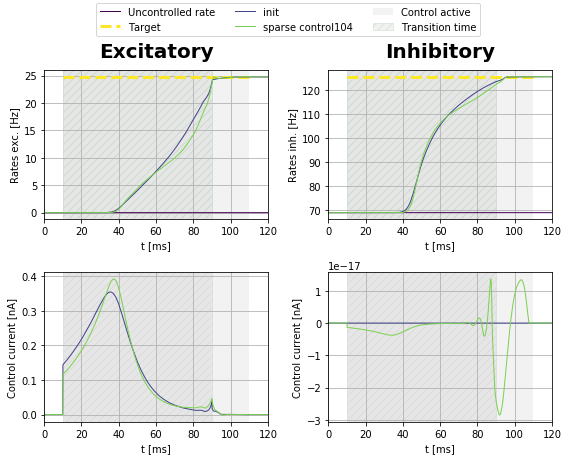

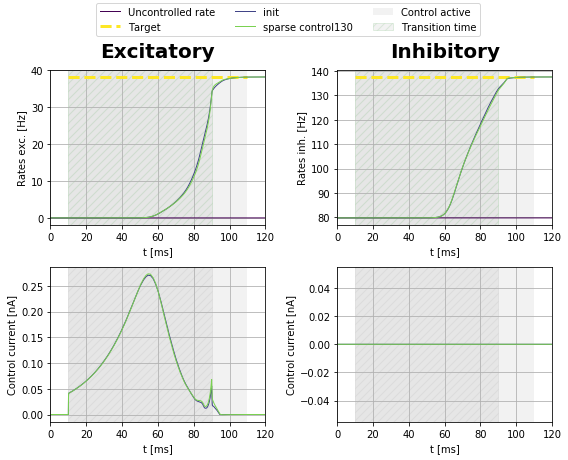

In [36]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [43]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  78 0.5250000000000001 0.6750000000000004
no convergence
weight =  6475.423568996675
set cost params:  1.0 0.0 6475.423568996675
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24570.498804832714
Gradient descend method:  None
RUN  1 , total integrated cost =  24570.497936401633
RUN  2 , total integrated cost =  24570.497828944808
RUN  3 , total integrated cost =  24570.497817798198
RUN  4 , total integrated cost =  24570.49781625626
RUN  5 , total integrated cost =  24570.49781605845
RUN  6 , total integrated cost =  24570.497816034895
RUN  7 , total integrated cost =  24570.49781603222
RUN  8 , total integrated cost =  24570.497816031853
RUN  9 , total integrated cost =  24570.49781603183


ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  24570.497816031817
RUN  11 , total integrated cost =  24570.497816031817
Control only changes marginally.
RUN  11 , total integrated cost =  24570.497816031817
Improved over  11  iterations in  1.4364126000000397  seconds by  4.024341976105461e-06  percent.
Problem in initial value trasfer:  Vmean_exc -56.70192223615503 -56.70192193030023
-------  104 0.4250000000000001 0.7750000000000005
no convergence
weight =  720.016006988042
set cost params:  1.0 0.0 720.016006988042
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6112.281045804066
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  6112.281045804066
Control only changes marginally.
RUN  1 , total integrated cost =  6112.281045804066
Improved over  1  iterations in  0.17557820000001811  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62564773979273 -56.62564415685167
-------  130 0.47500000000000014 0.8500000000000005
no convergence
weight =  2184.5418142672906
set cost params:  1.0 0.0 2184.5418142672906
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14541.304025677135
Gradient descend method:  None
RUN  1 , total integrated cost =  14541.304010116424
RUN  2 , total integrated cost =  14541.304009602289
RUN  3 , total integrated cost =  14541.304009589028
RUN  4 , total integrated cost =  14541.304009588775
RUN  5 , total integrated cost =  14541.304009588752


...

RUN  8 , total integrated cost =  24570.85871377951
Control only changes marginally.
RUN  8 , total integrated cost =  24570.85871377951
Improved over  8  iterations in  1.0902604000000338  seconds by  2.653166575328214e-11  percent.
Problem in initial value trasfer:  Vmean_exc -56.70192223605316 -56.70192193020226
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  130 0.47500000000000014 0.8500000000000005
no convergence
weight =  2184.5446053769315
set cost params:  1.0 0.0 2184.5446053769315
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14541.322570968143
Gradient descend method:  None
RUN  1 , total integrated cost =  14541.322570968143
Control only changes marginally.


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  14541.322570968143
Improved over  1  iterations in  0.17254190000016933  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.677168533800206 -56.67717172278038
--------------- 2
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  78 0.5250000000000001 0.6750000000000004
no convergence
weight =  6475.519256941769
set cost params:  1.0 0.0 6475.519256941769
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24570.859801981598
Gradient descend method:  None
RUN  1 , total integrated cost =  24570.859801981598
Control only changes marginally.
RUN  1 , total integrated cost =  24570.859801981598
Improved over  1  iterations in  0.1763472999998612  seconds by  0.0  percent.


ERROR:root:Problem in initial value trasfer


Problem in initial value trasfer:  Vmean_exc -56.70192223605316 -56.70192193020226
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
--------------- 3
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
--------------- 4
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  130 0.47500000000000014 0.8500000000000005
con

In [44]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [45]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [46]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [49]:
"""
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)
"""  

print(i_range_1)

[78, 104, 130]


In [ ]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  78 0.5250000000000001 0.6750000000000004
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  77.8594415230534
Gradient descend method:  None
RUN  1 , total integrated cost =  3.9046089461460043
RUN  2 , total integrated cost =  3.888934305981479
RUN  3 , total integrated cost =  3.884585718383214
RUN  4 , total integrated cost =  3.881471355993976
RUN  5 , total integrated cost =  3.880636326145893
RUN  6 , total integrated cost =  3.8798817681793913
RUN  7 , total integrated cost =  3.878090361842004
RUN  8 , total integrated cost =  3.876672430009761
RUN  9 , total integrated cost =  3.8760918212549504
RUN  10 , total integrated cost =  3.8756140494403364
RUN  11 , total integrated cost =  3.8744384403450036
RUN  12 , total integrated cost =  3.8735110483084725
RUN  13 , total integrated cost =  3.8730419198644457
RUN  14 , total integrated cost =  3.872643504956129
RUN  15 , total integrated cost =  3.871773512131859
RUN  16

In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False]]

ERROR:root:Problem in initial value trasfer



-------  13 0.47500000000000014 0.40000000000000013
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.5286173018767827
Gradient descend method:  None
RUN  1 , total integrated cost =  0.5286173018767827
Control only changes marginally.
RUN  1 , total integrated cost =  0.5286173018767827
Improved over  1  iterations in  0.06443299999999397  seconds by  0.0  percent.
-------  26 0.47500000000000014 0.4750000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.924750473324373
Gradient descend method:  None
RUN  1 , total integrated cost =  2.924750473324373
Control only changes marginally.
RUN  1 , total integrated cost =  2.924750473324373
Improved over  1  iterations in  0.06897790000000725  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.68752446458032 -56.687524435522484
-------  39 0.5250000000000001 0.5250000000

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  2.784608803708216
Control only changes marginally.
RUN  1 , total integrated cost =  2.784608803708216
Improved over  1  iterations in  0.07509129999999686  seconds by  0.0  percent.
-------  52 0.5500000000000003 0.5750000000000003
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.8577604711863382
Gradient descend method:  None
RUN  1 , total integrated cost =  2.8577604711863382
Control only changes marginally.
RUN  1 , total integrated cost =  2.8577604711863382
Improved over  1  iterations in  0.0676585000000074  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70439504617005 -56.70439517884657
-------  65 0.5500000000000003 0.6250000000000003
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4.350448448717619
Gradient descend method:  None
RUN  1 , total integrated cost =  4.3504484487176

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  7.487252981493506
Control only changes marginally.
RUN  1 , total integrated cost =  7.487252981493506
Improved over  1  iterations in  0.07153800000000388  seconds by  0.0  percent.
-------  104 0.4250000000000001 0.7750000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15.406147483418845
Gradient descend method:  None
RUN  1 , total integrated cost =  15.406147483418845
Control only changes marginally.
RUN  1 , total integrated cost =  15.406147483418845
Improved over  1  iterations in  0.06939770000001033  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62626751093135 -56.626256414571564
-------  117 0.5500000000000003 0.8000000000000005
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.906791512657174
Gradient descend method:  None
RUN  1 , total integrated cost =  3.906791512

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  12.859542158573662
Control only changes marginally.
RUN  1 , total integrated cost =  12.859542158573662
Improved over  1  iterations in  0.07251730000000123  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67733617342236 -56.67733700423722
-------  143 0.6000000000000003 0.8750000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7.029081176253722
Gradient descend method:  None
RUN  1 , total integrated cost =  7.029081176253722
Control only changes marginally.
RUN  1 , total integrated cost =  7.029081176253722
Improved over  1  iterations in  0.06899140000000159  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70025836911876 -56.70025982598458
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, 

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
